In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('SDC_sin_nulos.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       33 non-null     int64  
 1   Indicador        33 non-null     str    
 2   Enero, 24        33 non-null     float64
 3   Febrero, 24      33 non-null     float64
 4   Marzo, 24        33 non-null     float64
 5   Abril, 24        33 non-null     float64
 6   Mayo, 24         33 non-null     float64
 7   Junio, 24        33 non-null     float64
 8   Julio, 24        33 non-null     float64
 9   Agosto, 24       33 non-null     float64
 10  Septiembre, 24   33 non-null     float64
 11  Octubre, 24      33 non-null     float64
 12  Noviembre, 24    33 non-null     float64
 13  Diciembre, 25    33 non-null     float64
 14  Enero, 25        33 non-null     float64
 15  Febrero, 25      33 non-null     float64
 16  Marzo, 25        33 non-null     float64
 17  Abril, 25        33 non-null 

In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Unnamed: 0         0
Indicador          0
Enero, 24          0
Febrero, 24        0
Marzo, 24          0
Abril, 24          0
Mayo, 24           0
Junio, 24          0
Julio, 24          0
Agosto, 24         0
Septiembre, 24     0
Octubre, 24        0
Noviembre, 24      0
Diciembre, 25      0
Enero, 25          0
Febrero, 25        0
Marzo, 25          0
Abril, 25          0
Mayo, 25           0
Junio, 25          0
Julio, 25          0
Agosto, 25         0
Septiembre, 25     0
Octubre, 25        0
Noviembre, 25      0
Diciembre, 25.1    0
Enero, 26          0
Febrero, 26        0
Marzo, 26          0
Abril, 26          0
Mayo,26            0
Junio, 26          0
Julio,26           0
Total 2024         0
Total 2025         0
Total 2026         0
dtype: int64

In [6]:
#Creo 2 dataframe para poder procesar los outliers
cuantitativas= data.iloc[ : , 2:33 ]
cualitativas = data.iloc[:, [1, 33, 34, 35]]

<Figure size 1500x800 with 0 Axes>

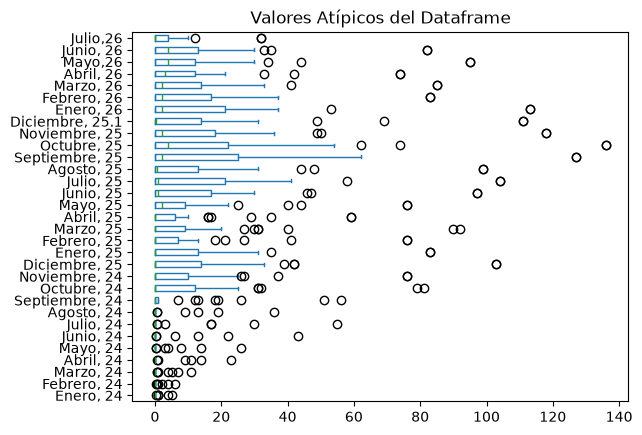

In [7]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [8]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Enero, 24            3.704023
Febrero, 24          4.227327
Marzo, 24            8.137889
Abril, 24           16.998936
Mayo, 24            17.305363
Junio, 24           28.115873
Julio, 24           37.494534
Agosto, 24          24.378016
Septiembre, 24      47.927447
Octubre, 24         72.612292
Noviembre, 24       69.651351
Diciembre, 25       93.416367
Enero, 25           75.556771
Febrero, 25         68.142142
Marzo, 25           82.411231
Abril, 25           55.220976
Mayo, 25            71.401166
Junio, 25           89.024454
Julio, 25           95.388521
Agosto, 25          91.010497
Septiembre, 25     116.037862
Octubre, 25        127.756730
Noviembre, 25      106.035214
Diciembre, 25.1    103.341285
Enero, 26          102.259397
Febrero, 26         74.689073
Marzo, 26           77.243682
Abril, 26           67.997048
Mayo,26             84.374794
Junio, 26           73.646357
Julio,26            28.127475
dtype: float64
Limite inferior permitido Ene

In [9]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data2= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data2

,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24","Octubre, 24",...,"Octubre, 25","Noviembre, 25","Diciembre, 25.1","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26"
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,2.000000,7.000000,14.000000,8.000000,13.000000,30.000000,19.000000,26.000000,31.000000,...,51.000000,49.000000,31.000000,37.000000,37.000000,41.000000,42.000000,44.000000,35.000000,12.000000
2,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,3.000000,0.000000,1.000000,32.000000,...,22.000000,32.000000,49.000000,34.000000,21.000000,14.000000,16.000000,17.000000,10.000000,9.000000
3,NaN,4.000000,4.000000,9.000000,14.000000,22.000000,17.000000,13.000000,13.000000,12.000000,...,62.000000,36.000000,28.000000,36.000000,25.000000,30.000000,16.000000,30.000000,33.000000,9.000000
4,1.0,1.000000,5.000000,11.000000,3.000000,6.000000,17.000000,9.000000,7.000000,14.000000,...,25.000000,24.000000,14.000000,21.000000,17.000000,18.000000,16.000000,19.000000,13.000000,4.000000
5,0.2,0.333333,0.636364,0.608696,0.307692,0.302326,0.545455,0.527778,0.464286,0.392405,...,0.375000,0.415254,0.279279,0.327434,0.445783,0.482353,0.567568,0.463158,0.426829,0.375000
6,1.0,0.500000,0.714286,0.785714,0.375000,0.461538,0.566667,0.473684,0.269231,0.451613,...,0.490196,0.489796,0.451613,0.567568,0.459459,0.439024,0.380952,0.431818,0.371429,0.333333
7,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data2.isnull().sum()
valores_nulos

Enero, 24          2
Febrero, 24        1
Marzo, 24          1
Abril, 24          1
Mayo, 24           1
Junio, 24          1
Julio, 24          1
Agosto, 24         1
Septiembre, 24     2
Octubre, 24        2
Noviembre, 24      2
Diciembre, 25      2
Enero, 25          2
Febrero, 25        2
Marzo, 25          2
Abril, 25          2
Mayo, 25           2
Junio, 25          2
Julio, 25          2
Agosto, 25         2
Septiembre, 25     2
Octubre, 25        2
Noviembre, 25      2
Diciembre, 25.1    2
Enero, 26          2
Febrero, 26        2
Marzo, 26          2
Abril, 26          2
Mayo,26            2
Junio, 26          2
Julio,26           2
dtype: int64

In [11]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data2.copy()
data_clean=data_clean.fillna(round(data2.mean(),1))
data_clean

,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24","Octubre, 24",...,"Octubre, 25","Noviembre, 25","Diciembre, 25.1","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26"
0,0.1,0.200000,0.600000,1.100000,0.900000,1.300000,2.100000,1.300000,3.200000,5.500000,...,12.500000,9.900000,8.900000,9.400000,7.100000,7.600000,6.400000,8.000000,7.200000,2.200000
1,1.0,2.000000,7.000000,14.000000,8.000000,13.000000,30.000000,19.000000,26.000000,31.000000,...,51.000000,49.000000,31.000000,37.000000,37.000000,41.000000,42.000000,44.000000,35.000000,12.000000
2,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,3.000000,0.000000,1.000000,32.000000,...,22.000000,32.000000,49.000000,34.000000,21.000000,14.000000,16.000000,17.000000,10.000000,9.000000
3,0.1,4.000000,4.000000,9.000000,14.000000,22.000000,17.000000,13.000000,13.000000,12.000000,...,62.000000,36.000000,28.000000,36.000000,25.000000,30.000000,16.000000,30.000000,33.000000,9.000000
4,1.0,1.000000,5.000000,11.000000,3.000000,6.000000,17.000000,9.000000,7.000000,14.000000,...,25.000000,24.000000,14.000000,21.000000,17.000000,18.000000,16.000000,19.000000,13.000000,4.000000
5,0.2,0.333333,0.636364,0.608696,0.307692,0.302326,0.545455,0.527778,0.464286,0.392405,...,0.375000,0.415254,0.279279,0.327434,0.445783,0.482353,0.567568,0.463158,0.426829,0.375000
6,1.0,0.500000,0.714286,0.785714,0.375000,0.461538,0.566667,0.473684,0.269231,0.451613,...,0.490196,0.489796,0.451613,0.567568,0.459459,0.439024,0.380952,0.431818,0.371429,0.333333
7,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.200000,5.500000,...,12.500000,9.900000,8.900000,9.400000,7.100000,7.600000,6.400000,8.000000,7.200000,2.200000
9,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

Enero, 24          0
Febrero, 24        0
Marzo, 24          0
Abril, 24          0
Mayo, 24           0
Junio, 24          0
Julio, 24          0
Agosto, 24         0
Septiembre, 24     0
Octubre, 24        0
Noviembre, 24      0
Diciembre, 25      0
Enero, 25          0
Febrero, 25        0
Marzo, 25          0
Abril, 25          0
Mayo, 25           0
Junio, 25          0
Julio, 25          0
Agosto, 25         0
Septiembre, 25     0
Octubre, 25        0
Noviembre, 25      0
Diciembre, 25.1    0
Enero, 26          0
Febrero, 26        0
Marzo, 26          0
Abril, 26          0
Mayo,26            0
Junio, 26          0
Julio,26           0
dtype: int64

In [13]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data_clean], axis=1)
Datos_limpios

,Indicador,Total 2024,Total 2025,Total 2026,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24",...,"Octubre, 25","Noviembre, 25","Diciembre, 25.1","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26"
0,Generadas,519,1178,450,0.1,0.200000,0.600000,1.100000,0.900000,1.300000,...,12.500000,9.900000,8.900000,9.400000,7.100000,7.600000,6.400000,8.000000,7.200000,2.200000
1,Aprobadas,215,451,201,1.0,2.000000,7.000000,14.000000,8.000000,13.000000,...,51.000000,49.000000,31.000000,37.000000,37.000000,41.000000,42.000000,44.000000,35.000000,12.000000
2,Condicionadas,100,287,102,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,...,22.000000,32.000000,49.000000,34.000000,21.000000,14.000000,16.000000,17.000000,10.000000,9.000000
3,Rechazadas,163,392,137,0.1,4.000000,4.000000,9.000000,14.000000,22.000000,...,62.000000,36.000000,28.000000,36.000000,25.000000,30.000000,16.000000,30.000000,33.000000,9.000000
4,Formalizadas,105,234,91,1.0,1.000000,5.000000,11.000000,3.000000,6.000000,...,25.000000,24.000000,14.000000,21.000000,17.000000,18.000000,16.000000,19.000000,13.000000,4.000000
5,% de Aprobación,0.4142581888246628,0.3828522920203735,0.44666666666666666,0.2,0.333333,0.636364,0.608696,0.307692,0.302326,...,0.375000,0.415254,0.279279,0.327434,0.445783,0.482353,0.567568,0.463158,0.426829,0.375000
6,% de Formalizacion,0.4883720930232558,0.5188470066518847,0.4527363184079602,1.0,0.500000,0.714286,0.785714,0.375000,0.461538,...,0.490196,0.489796,0.451613,0.567568,0.459459,0.439024,0.380952,0.431818,0.371429,0.333333
7,N.º de solicitudes ingresadas por financiera,0,0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Financiera,TOTAL,% PARTICIPACION,-,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,12.500000,9.900000,8.900000,9.400000,7.100000,7.600000,6.400000,8.000000,7.200000,2.200000
9,ABC,1,0.0005184033177812338,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [14]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Indicador          0
Total 2024         0
Total 2025         0
Total 2026         0
Enero, 24          0
Febrero, 24        0
Marzo, 24          0
Abril, 24          0
Mayo, 24           0
Junio, 24          0
Julio, 24          0
Agosto, 24         0
Septiembre, 24     0
Octubre, 24        0
Noviembre, 24      0
Diciembre, 25      0
Enero, 25          0
Febrero, 25        0
Marzo, 25          0
Abril, 25          0
Mayo, 25           0
Junio, 25          0
Julio, 25          0
Agosto, 25         0
Septiembre, 25     0
Octubre, 25        0
Noviembre, 25      0
Diciembre, 25.1    0
Enero, 26          0
Febrero, 26        0
Marzo, 26          0
Abril, 26          0
Mayo,26            0
Junio, 26          0
Julio,26           0
dtype: int64

In [15]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("SDC_sin_valores_atipicos.csv")